In [1]:
import dask.dataframe as dd

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [4]:
dd.read_csv("/mnt/research/CMSE495-SS24-ICER/file_system_usage/gpfs-stats/inode-size-age-jan-23", delimiter=' ', blocksize=25e5)

,100663296,0,8,1447,1447.1,3131,1447.2,2035,762231
npartitions=28769,,,,,,,,,
,int64,int64,int64,int64,int64,int64,int64,int64,int64
,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...


In [16]:
column_names = ["Inode (file unique ID)",
"KB Allocated",
"File Size",
"Creation Time in days from today",
"Change Time in days from today",
"Modification time in days from today",
"Last Modified",
"GID numeric ID for the group owner of the file",
"UID numeric ID for the owner of the file"]

In [17]:
df = pd.read_csv("/mnt/research/CMSE495-SS24-ICER/file_system_usage/gpfs-stats/inode-size-age-jan-23",header=None, names = column_names , sep=" ", nrows=2000000)
df

,Inode (file unique ID),KB Allocated,File Size,Creation Time in days from today,Change Time in days from today,Modification time in days from today,Last Modified,GID numeric ID for the group owner of the file,UID numeric ID for the owner of the file
0,100663296,0,8,1447,1447,3131,1447,2035,762231
1,100663297,0,188,1447,1447,1937,1447,2010,614955
2,100663301,0,567,1447,1447,3142,1447,2035,762231
3,100663304,0,87,1447,1447,3142,1447,2035,762231
4,100663306,0,1689,1447,1447,1937,1447,2010,614955
...,...,...,...,...,...,...,...,...,...
1999995,103171960,0,1911,1447,1447,1553,1378,2003,785573
1999996,103171961,0,558,1447,1447,1492,1446,2010,841154
1999997,103171962,0,0,1447,1093,1992,1506,2022,500120
1999998,103171963,64,4792,1447,1447,1553,1378,2003,785573


In [ ]:
df.tail()

In [8]:
df.describe()

,Inode (file unique ID),KB Allocated,File Size,Creation Time in days from today,Change Time in days from today,Modification time in days from today,Last Used,GID numeric ID for the group owner of the file,UID numeric ID for the owner of the file
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,1.018889e+08,9.481431e+02,1.292270e+06,1.377379e+03,1.338648e+03,2.078515e+03,1.306128e+03,2.049434e+03,9.355708e+07
std,7.237569e+05,7.630898e+04,1.038634e+08,2.504340e+02,2.639683e+02,7.244308e+02,3.126733e+02,9.394009e+01,2.900373e+08
min,1.006633e+08,0.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.012598e+08,0.000000e+00,6.120000e+02,1.447000e+03,1.447000e+03,1.715000e+03,1.366000e+03,2.010000e+03,7.535590e+05
50%,1.018647e+08,0.000000e+00,3.520000e+03,1.447000e+03,1.447000e+03,1.999000e+03,1.446000e+03,2.022000e+03,7.855730e+05
75%,1.025160e+08,6.400000e+01,1.310000e+04,1.447000e+03,1.447000e+03,2.371000e+03,1.447000e+03,2.035000e+03,8.411540e+05
max,1.031720e+08,5.252851e+07,5.379754e+10,1.447000e+03,1.447000e+03,1.786500e+04,1.653000e+03,2.424000e+03,1.000000e+09


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 9 columns):
 #   Column                                          Dtype
---  ------                                          -----
 0   Inode (file unique ID)                          int64
 1   KB Allocated                                    int64
 2   File Size                                       int64
 3   Creation Time in days from today                int64
 4   Change Time in days from today                  int64
 5   Modification time in days from today            int64
 6   Last Used                                       int64
 7   GID numeric ID for the group owner of the file  int64
 8   UID numeric ID for the owner of the file        int64
dtypes: int64(9)
memory usage: 137.3 MB


In [10]:
df.nunique()

Inode (file unique ID)                            1986353
KB Allocated                                         2107
File Size                                          181668
Creation Time in days from today                      791
Change Time in days from today                        840
Modification time in days from today                 3844
Last Used                                             898
GID numeric ID for the group owner of the file         21
UID numeric ID for the owner of the file               24
dtype: int64

In [11]:
df["Last Used"]

0          1447
1          1447
2          1447
3          1447
4          1447
           ... 
1999995    1378
1999996    1446
1999997    1506
1999998    1378
1999999    1446
Name: Last Used, Length: 2000000, dtype: int64

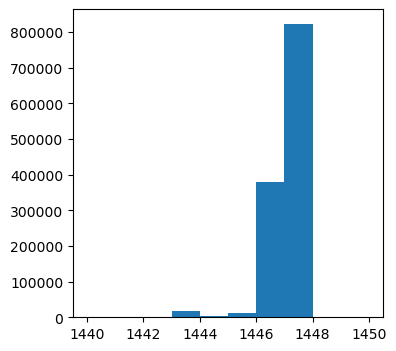

In [42]:
plt.figure(figsize=(4,4))
plt.hist(df["Last Modified"], bins=10, range=[1440,1450])
plt.show()

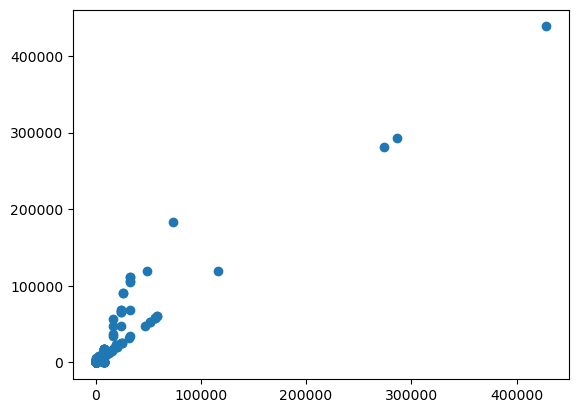

In [36]:
plt.scatter(df['KB Allocated'], df['File Size']/1000)
plt.xlabel('KB Allocated (what the user requested)')
plt.ylabel('KB of the file size')